In [1]:

import gropt
from gropt.plot import plot_diff
from gropt.diff import diff_min_TE
import numpy as np
import sys
sys.path.append('../utils/')
from stim_code_utils import diff_min_TE_base, make_stim_envelope # My modified version of diff_min_TE 
from trap_diffusion import *
from plot_utils import *
import os


In [2]:
# First define some common params across all examples
# Here we are simulating a 1.5 x 1.5 x 1.5 isotropic resolution with 6/8 PF and GRAPPA x 2

base_params = {
    'T_90': 2.835e-3,  # Duration of the 90° RF pulse [s]
    'T_180': 7.07e-3,  # Duration of the 180° RF pulse [s]
    'T_180_center': 0.00354075, # Center of the 180° RF pulse relative to its start [s]
    'T_readout': 13.734e-3,  # [s]
    'gmax': .190,  # Maximum gradient amplitude [T/m]
    'smax': 200,  # Maximum gradient slewrate [T/m/s]
    'MMT': 1,  # Moment order to null up to, so 2 = M0+M1+M2 nulling, 1 = M0+M1, 0 = M0
    'dt': 250e-6,  # Gradient waveform step size [s]
    'bvalue': 1000,  # Diffusion weighting [s/mm^2]
    }


# Right now these are the real constants but need to change slightly in final verison
safe = {'tau1': np.array([0.0008, 0.0008, 0.0008]),
 'tau2': np.array([0.012, 0.012, 0.012]),
 'tau3': np.array([0.000212, 0.000194, 0.000184]),
 'a1': np.array([0.297, 0.213, 0.275]),
 'a2': np.array([0.5, 0.5, 0.5]),
 'a3': np.array([0.203, 0.287, 0.225]),
 'stim_limit': np.array([34.725, 23.202, 31.168]),
 'g_scale': np.array([0.3324, 0.3369, 0.3059])}


# For CNS typically all 3 axis have the same limits 
safe_cardiac = {'tau1': np.array([0.0026, 0.0026, 0.0026]),
 'tau2': np.array([0.0018, 0.0018, 0.0018]),
 'tau3': np.array([0.001, 0.001, 0.001]),
 'a1': np.array([0.743, 0.743, 0.743]),
 'a2': np.array([0.257, 0.257, 0.257]),
 'a3': np.array([0, 0, 0]),
 'stim_limit': np.array([17.15, 17.38, 15.78]),
 'g_scale': np.array([0.3324, 0.3369, 0.3059])}



# Conventional Diffusion Encoding

Making trapezoid waveform (binary search)...
Start TE is 34.52 ms
Searching TE:  92.26 63.39 77.82 70.60 74.21 72.41 71.51 71.96 71.73 71.84 71.90 71.93 71.91 
Best TE found with binary search: 71.930 ms, b-value: 1000.0000000000025


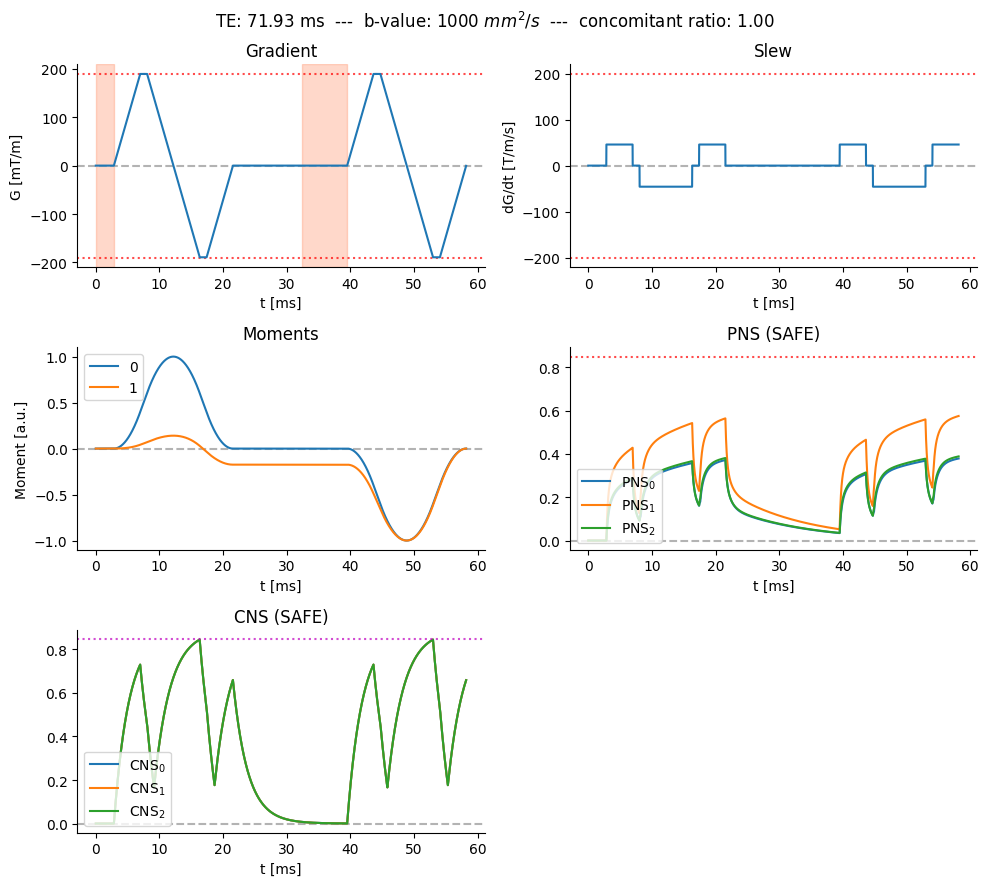

In [3]:
# Inherit base parameters; define some additional limits
trap_params = {**base_params,
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 'pns_params': safe,   
          'cns_params': safe_cardiac,'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

trap_params['dt'] = 10e-6 # we can use smaller dt for trapezoids

# define a trapezoid object 
trap_obj = GetMinTE_Trap(trap_params, 
                gmaxRange=[0.100, trap_params['gmax']], # range of gmax to search over
                smaxRange=  np.concatenate(([200], np.arange(120, 20, -2))),) # range of smax to search over

# run binary search to find minimum TE and corresponding gradient waveform
TE_trap, g_waveform_trap, t_array, bval_trap, timings_trap = trap_obj.compute_binary()

# plot the results
plot_diff(g_waveform_trap, trap_params['dt'], TE = TE_trap, params = trap_params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE Diffusion-Encoding: Constant Threshold

starting TE search: 0.021, 0.09

Searching TE: 55.50 !38.25[2026-04-25 23:36:46.639] [error] Large values detected in Xhat at iteration 20. Stopping solver.
 !46.87[2026-04-25 23:36:47.576] [error] Large values detected in Xhat at iteration 2607. Stopping solver.
 51.19 53.34 54.42 53.88 53.61 Done!


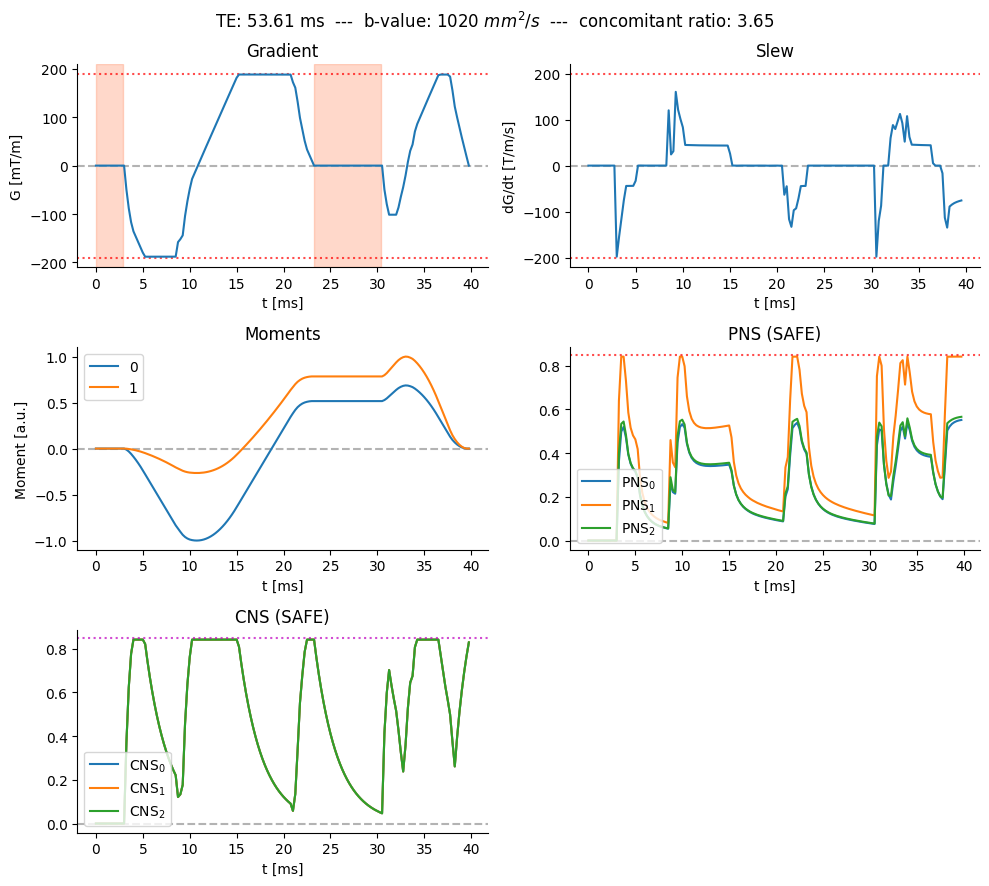

In [4]:
# Inherit base parameters; define some additional limits
params = {**base_params,
            'dt': 250e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 'pns_params': safe,   
          'cns_params': safe_cardiac,'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 90e-3)

if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE: Arbitrary Envelope Function
Define a vector instead of a constant threshold, but it is arbitrarily defined

starting TE search: 0.021, 0.09

Searching TE: 55.50 !38.25[2026-04-25 23:17:40.606] [error] Large values detected in Xhat at iteration 15. Stopping solver.
 [2026-04-25 23:17:40.628] [error] Large values detected in Xhat at iteration 56. Stopping solver.
!46.87 51.19 53.34 54.42 53.88 53.61 Done!


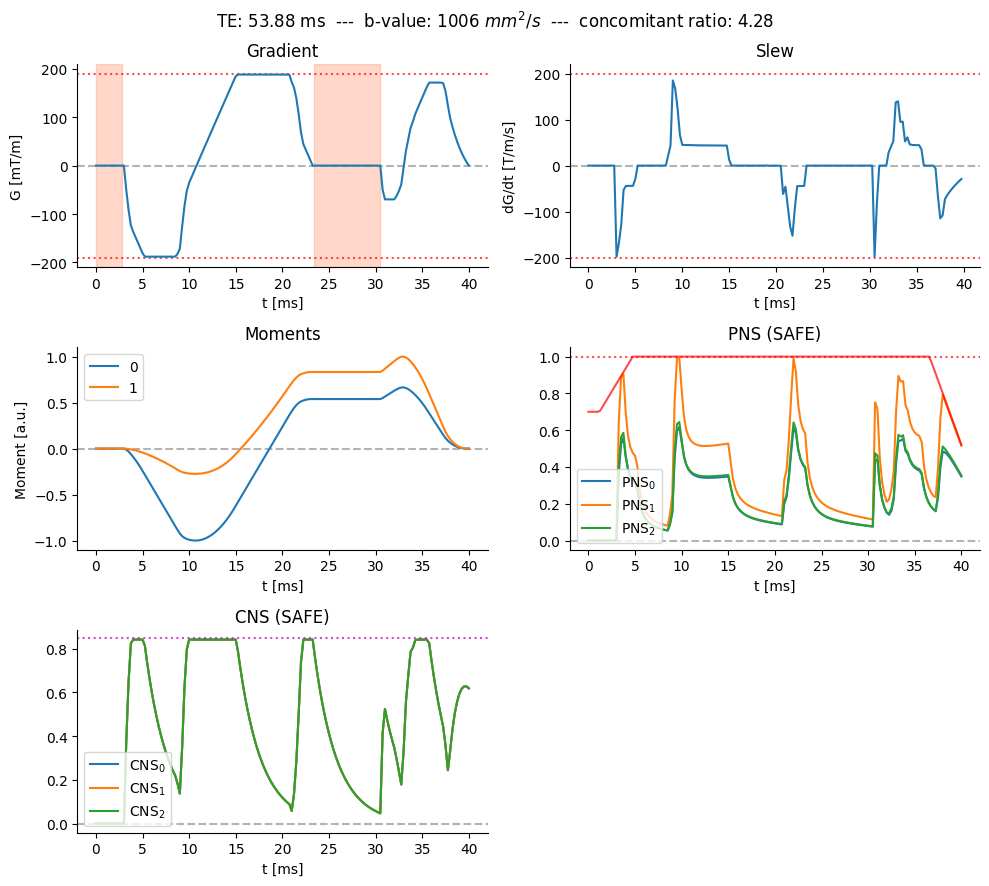

In [5]:
# Make an arbitrary envelope that ra
stim_vec = make_stim_envelope(params,TE = 90e-3, start_val = 0.7, end_val = 0.5, T_ramp = 7e-3)

# Inherit base parameters; define some additional limits
params = {**base_params,
           'dt': 250e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': stim_vec, 'pns_params': safe,   
          'cns_params': safe_cardiac,'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 90e-3)

if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE: Envelope Function based on Sequence 
Define a vector based on the gradient waveforms from other gradient events

starting TE search: 0.020900000000000002, 0.07

Searching TE: !45.45[2026-04-25 23:37:01.999] [error] Large values detected in Xhat at iteration 22. Stopping solver.
 57.73 51.59 54.66 53.12 53.89 54.27 54.08 Done!


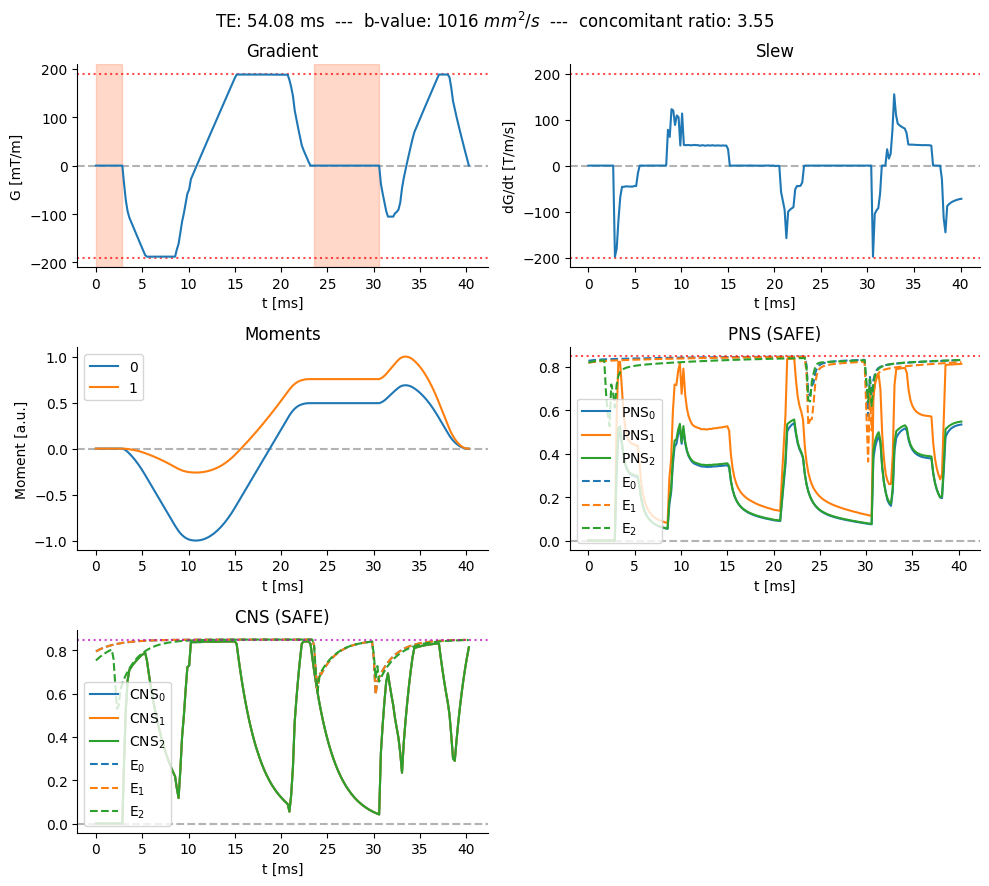

In [5]:
# currently designing envelope takes .mat files with waveforms and timings from pulseq in the future will design envelope based on dictionary
timings_file = 'diffusion_timing_parameters.mat' # timings in seconds 
waveforms_file = 'diffusion_timing_parameters_waveforms.mat' # right now units are in Hz/m for gradients in future will be mT/m or T/m

# to construct envelope in demo, you need the waveforms and timing parameters of a sequence 
# for this example, they are stored in the waveforms file, timings match the original timings

# Inherit base parameters; define some additional limits
params = {**base_params,
           'dt': 190e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 
          'pns_params': safe, 'cns_params': safe_cardiac,
          'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 70e-3, 
            timings_file=timings_file,  # envelope will be constructed based on timings
            waveforms_file=waveforms_file, # envelope constructed based on waveforms_file
            seq_repeats = 5) # number of sequence repeats for steady state envelope (if undefined, will do 5 repeat)


if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, 
              pns_params = safe,cns_params = safe_cardiac,
              timings_file=timings_file, waveforms_file=waveforms_file, seq_repeats = 5)